# Seasonal Agriculture Performance Analysis

**Name:** Salendra Singh Yadav
**College:** Chitkara University, HP
**AICTE STU ID:** STU6a69a32dee0e41785307949

**Objective:** Analyze the seasonal agriculture dataset to find how crop yield, resource usage and profitability change across the Kharif, Rabi and Zaid seasons, and to pull out patterns that can support better seasonal planning.

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

## 2. Loading the Dataset

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
print("Rows, Columns:", df.shape)
df.info()

Rows, Columns: (4000, 28)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 40

In [4]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## 3. Data Cleaning

Before doing any analysis, I checked the dataset for missing values, duplicate rows and anything that looked off.

In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


`Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` have some missing values. Since these values naturally differ a lot from one season to another (e.g. rainfall in Kharif vs Zaid), filling them with the overall column mean would be misleading. Instead I filled each missing value with the **median of its own season**, which keeps the seasonal character of the data intact.

In [7]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

df.isnull().sum().sum()

np.int64(0)

I also checked a few numeric columns for unrealistic/negative values that don't make physical sense (e.g. negative area or negative yield).

In [8]:
check_cols = ['Farm_Area_Hectares', 'Yield_Tonnes_Ha', 'Water_Used_m3', 'Production_Tonnes']
for c in check_cols:
    print(c, "-> min:", df[c].min(), " max:", df[c].max())

Farm_Area_Hectares -> min: 0.5  max: 15.0
Yield_Tonnes_Ha -> min: 0.3  max: 101.44
Water_Used_m3 -> min: 128  max: 40902
Production_Tonnes -> min: 0.15  max: 1424.4


Values look reasonable (Profit and net returns are allowed to be negative since a farm can genuinely run at a loss in a bad season, so those are kept as-is). No rows were dropped for cleaning - only missing values were imputed.

In [9]:
df['Season'] = df['Season'].str.strip()
df['Crop'] = df['Crop'].str.strip()
df['Irrigation_Method'] = df['Irrigation_Method'].str.strip()
df['Season'].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

## 4. Season-wise Overview

Kharif has the most records, followed by Rabi and then Zaid, which matches real cropping patterns in India (Zaid is a short summer season grown on a smaller scale).

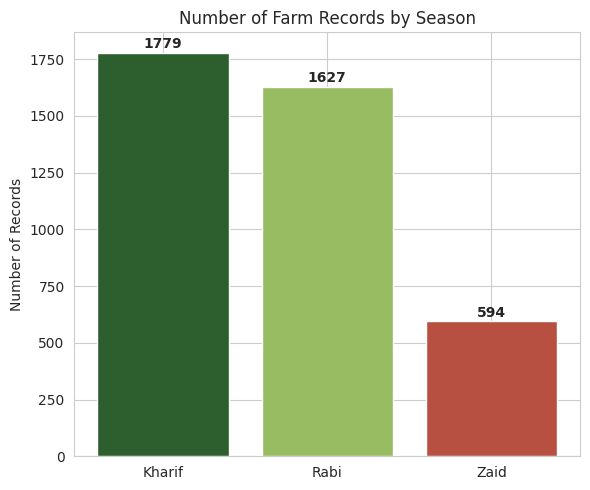

In [10]:
season_counts = df['Season'].value_counts()

plt.figure(figsize=(6,5))
colors = ['#2C5F2D', '#97BC62', '#B85042']
plt.bar(season_counts.index, season_counts.values, color=colors)
plt.title('Number of Farm Records by Season')
plt.ylabel('Number of Records')
for i, v in enumerate(season_counts.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_season_counts.png', dpi=150)
plt.show()

## 5. Yield and Profit Across Seasons

This is the core of the problem statement - how does agricultural performance actually change from one season to another?

In [11]:
season_summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR', 'Revenue_INR',
                                          'Total_Cost_INR', 'Water_Efficiency_t_per_1000m3',
                                          'Disease_Pest_Risk_pct']].mean().round(2)
season_summary

,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Total_Cost_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,5.63,178914.65,710719.06,531804.41,5.89,54.47
Rabi,5.04,87689.47,601526.05,513836.58,5.19,40.48
Zaid,4.64,-24804.82,519171.90,543976.73,4.41,38.22


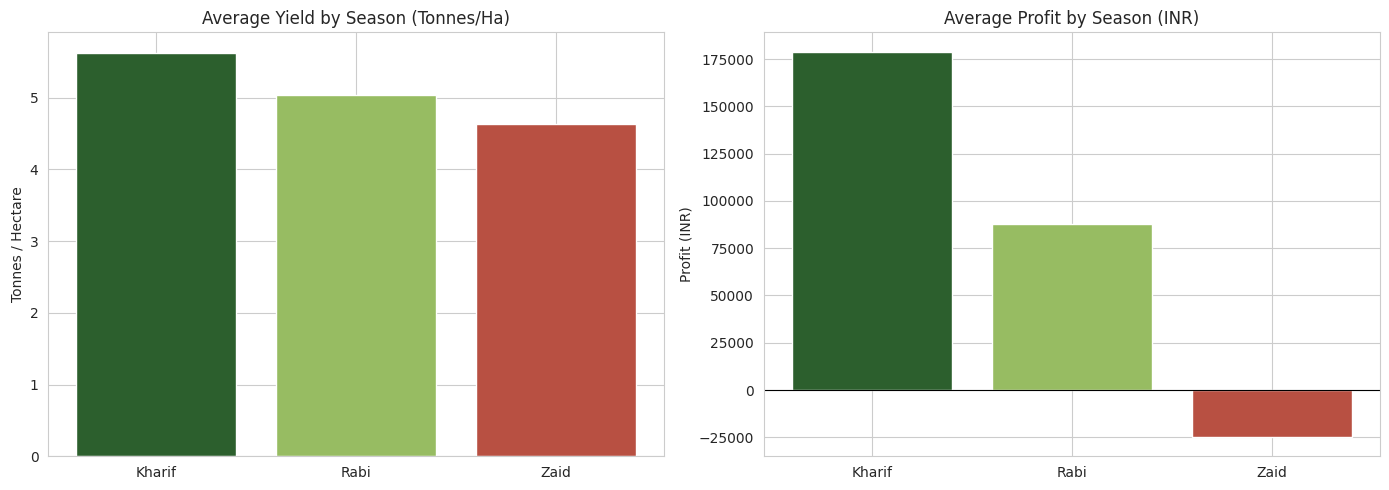

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_order = ['Kharif', 'Rabi', 'Zaid']
colors = ['#2C5F2D', '#97BC62', '#B85042']

axes[0].bar(season_order, season_summary.loc[season_order, 'Yield_Tonnes_Ha'], color=colors)
axes[0].set_title('Average Yield by Season (Tonnes/Ha)')
axes[0].set_ylabel('Tonnes / Hectare')

axes[1].bar(season_order, season_summary.loc[season_order, 'Profit_INR'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Profit by Season (INR)')
axes[1].set_ylabel('Profit (INR)')

plt.tight_layout()
plt.savefig('chart_yield_profit_by_season.png', dpi=150)
plt.show()

**Observation:** Kharif gives both the highest yield and the highest profit on average, mainly because it relies on monsoon rainfall and lower irrigation cost. Zaid, on the other hand, is running at an average **loss**, most likely because of higher temperatures and higher water/irrigation dependence in that season.

## 6. Spread and Variability - Boxplots

/tmp/ipykernel_1096/1471019154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, order=season_order, palette=colors, ax=axes[0])
/tmp/ipykernel_1096/1471019154.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Profit_INR', data=df, order=season_order, palette=colors, ax=axes[1])


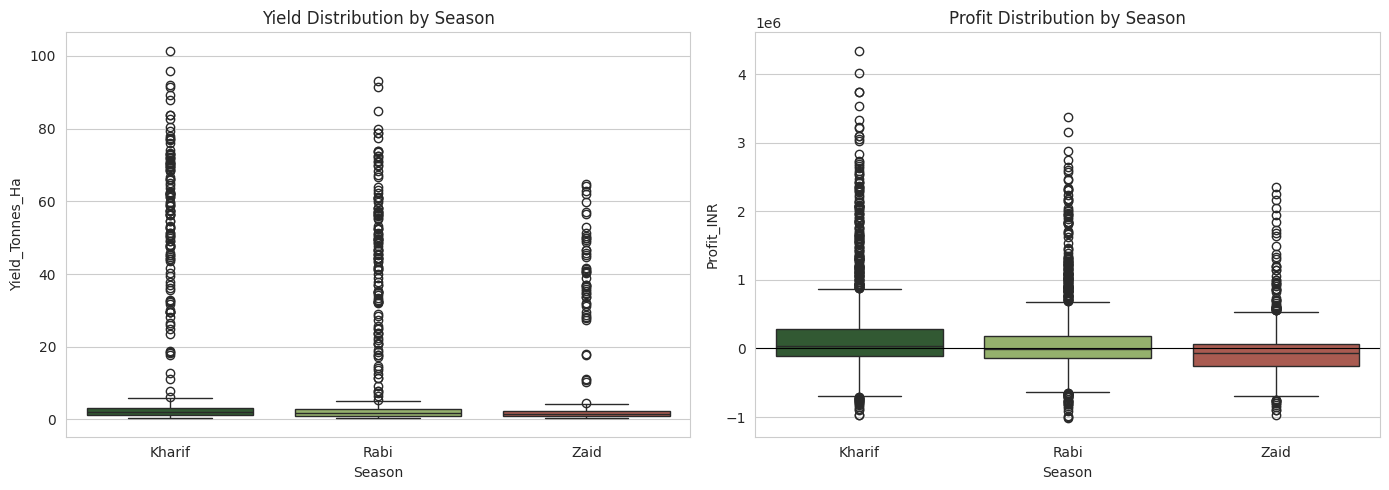

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, order=season_order, palette=colors, ax=axes[0])
axes[0].set_title('Yield Distribution by Season')

sns.boxplot(x='Season', y='Profit_INR', data=df, order=season_order, palette=colors, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Profit Distribution by Season')

plt.tight_layout()
plt.savefig('chart_boxplots_season.png', dpi=150)
plt.show()

Zaid shows a much wider spread in profit (many farms deep in loss, a few still doing fine), which tells us the risk in that season is higher and not just the average - some farmers are managing to make it work, most are not.

## 7. Statistical Test - Is the Difference Real?

A visual difference is not enough on its own, so I ran a one-way ANOVA to check if the season-wise differences are statistically significant, or if they could just be random variation.

In [14]:
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield   = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield   = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print("Yield ANOVA (all crops pooled together)")
print(f"F-statistic: {f_stat:.3f}   P-value: {p_value:.5f}")

Yield ANOVA (all crops pooled together)
F-statistic: 1.554   P-value: 0.21156


Interestingly, this test comes out **not significant** (p > 0.05). That surprised me at first, but it makes sense once I thought about it: yield values are pooled across very different crops (Sugarcane yields are 40-50+ t/ha while Pulses is under 1 t/ha), so the huge crop-to-crop variance drowns out the season effect when everything is mixed together.

So I checked two things instead: (1) profit across seasons, which isn't crop-scale dependent in the same way, and (2) yield across seasons **within a single crop**, to remove the crop-mix noise.

In [15]:
kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit   = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit   = df[df['Season'] == 'Zaid']['Profit_INR']

f_stat_p, p_value_p = stats.f_oneway(kharif_profit, rabi_profit, zaid_profit)
print("Profit ANOVA (all crops pooled together)")
print(f"F-statistic: {f_stat_p:.3f}   P-value: {p_value_p:.2e}")

rice = df[df['Crop'] == 'Rice']
f_stat_r, p_value_r = stats.f_oneway(*[rice[rice['Season'] == s]['Yield_Tonnes_Ha'] for s in season_order])
print("\nYield ANOVA for Rice only, across seasons")
print(f"F-statistic: {f_stat_r:.3f}   P-value: {p_value_r:.2e}")

Profit ANOVA (all crops pooled together)
F-statistic: 34.292   P-value: 1.71e-15

Yield ANOVA for Rice only, across seasons
F-statistic: 22.238   P-value: 4.38e-10


**Profit differs very significantly across seasons** (p is extremely small), which matches the big gap we already saw between Kharif and Zaid. And once crop type is held constant (Rice only), **yield across seasons is also highly significant**. So the seasonal effect is real - it was just being hidden in the first test by the fact that different crops have very different yield scales.

## 8. Crop-wise Yield Across Seasons

Since the dataset has multiple crops, it's worth checking whether the seasonal pattern holds for every crop or is driven mainly by one or two crops.

In [16]:
crop_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean').round(2)
crop_season_yield = crop_season_yield[season_order]
crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.19
Cotton,1.38,1.20,0.96
Groundnut,1.49,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.66
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.28,38.42
Wheat,2.25,2.06,1.75


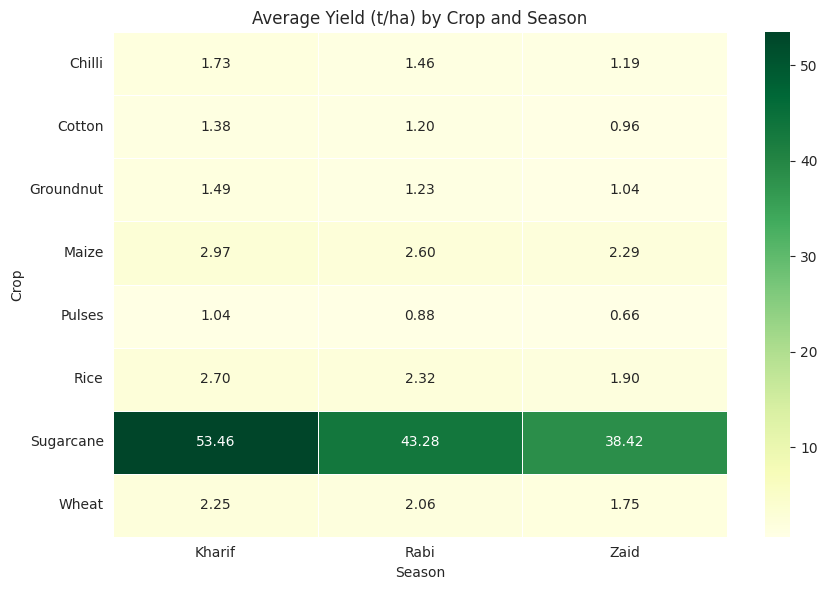

In [17]:
plt.figure(figsize=(9, 6))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)
plt.title('Average Yield (t/ha) by Crop and Season')
plt.tight_layout()
plt.savefig('chart_crop_season_heatmap.png', dpi=150)
plt.show()

Sugarcane yield numbers are naturally much larger than every other crop (it's a heavy-tonnage crop), which is expected. Looking past that, almost every crop follows the same order - **Kharif > Rabi > Zaid** - which means the seasonal drop is a general pattern in the data and not caused by just one crop.

## 9. Irrigation Method vs Profitability

Since resource usage was one of the things to investigate, I compared how profit varies by irrigation method within each season.

In [18]:
irr_profit = df.pivot_table(values='Profit_INR', index='Irrigation_Method', columns='Season', aggfunc='mean').round(0)
irr_profit = irr_profit[season_order]
irr_profit

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,317222.0,187843.0,21292.0
Flood,133374.0,58825.0,-69787.0
Rainfed,158974.0,45232.0,-79467.0
Sprinkler,116880.0,76502.0,57909.0


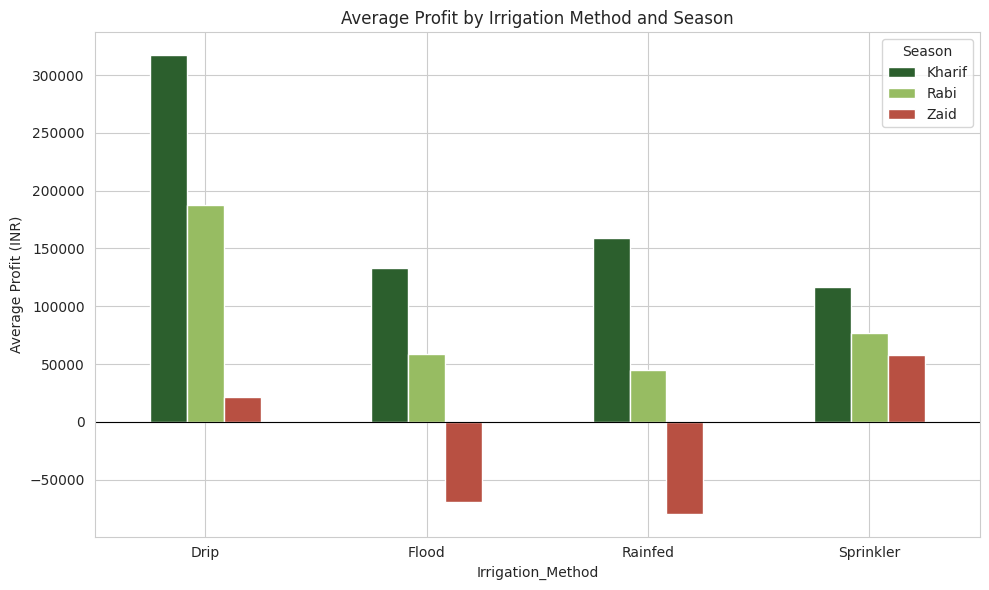

In [19]:
irr_profit.plot(kind='bar', figsize=(10,6), color=colors)
plt.title('Average Profit by Irrigation Method and Season')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('chart_irrigation_profit.png', dpi=150)
plt.show()

**Drip irrigation** clearly gives the best returns in Kharif and Rabi, well ahead of the other three methods. Interestingly, in Zaid the order changes a bit - **Sprinkler irrigation** actually edges out Drip (₹57,909 vs ₹21,292 average profit), while Flood and Rainfed both run losses in that season. So Drip isn't universally "the best" - it's the strongest choice for the main growing seasons, but Sprinkler seems to handle Zaid's hot, low-rainfall conditions slightly better. Either way, the bigger takeaway is that **Flood and Rainfed irrigation are the ones that turn Zaid into a loss-making season** - switching those farms to Drip or Sprinkler would likely help the most.

## 10. Relationship Between Environmental Conditions and Performance

Checking how weather/environmental variables relate to yield and profit using a correlation heatmap.

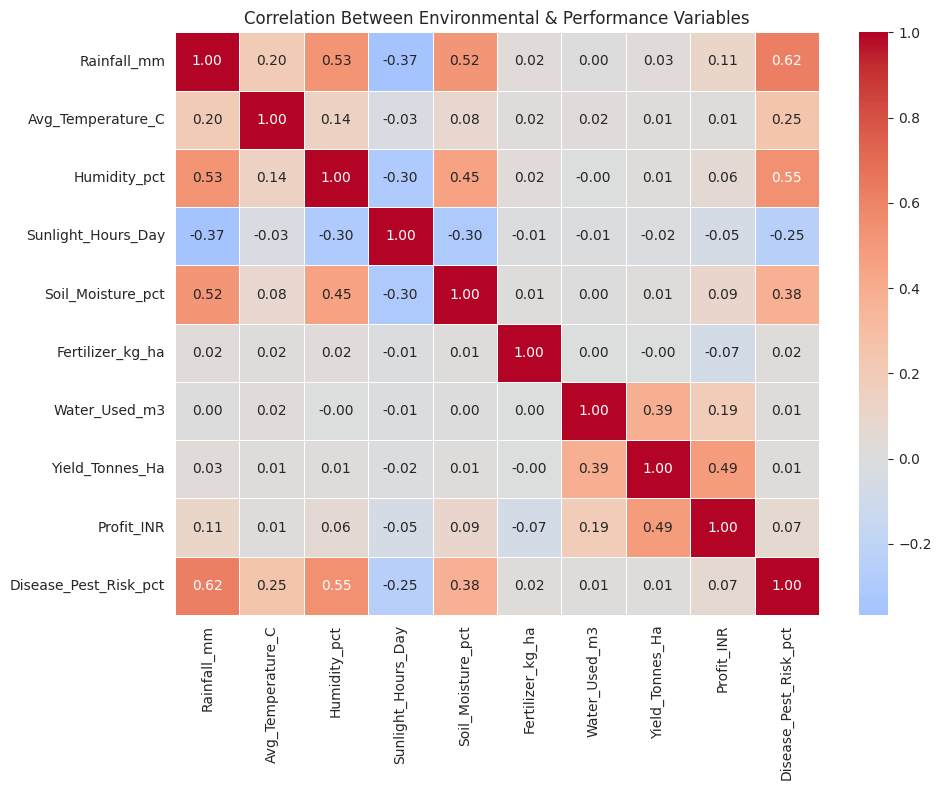

In [20]:
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
            'Soil_Moisture_pct', 'Fertilizer_kg_ha', 'Water_Used_m3',
            'Yield_Tonnes_Ha', 'Profit_INR', 'Disease_Pest_Risk_pct']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Between Environmental & Performance Variables')
plt.tight_layout()
plt.savefig('chart_correlation_heatmap.png', dpi=150)
plt.show()

Water used and yield show a moderate positive correlation (0.39), and yield-profit move together fairly closely (0.49), which makes sense - better yield generally means better returns. The strongest relationships in the data, though, are around disease/pest risk: it rises with rainfall (0.62) and humidity (0.55), confirming that the wet, humid monsoon conditions of Kharif are what's driving up pest pressure in that season. Sunlight hours has a mild negative relationship with most of these, since more rain/humidity usually means fewer sunlight hours in a day.

## 11. Disease & Pest Risk Across Seasons

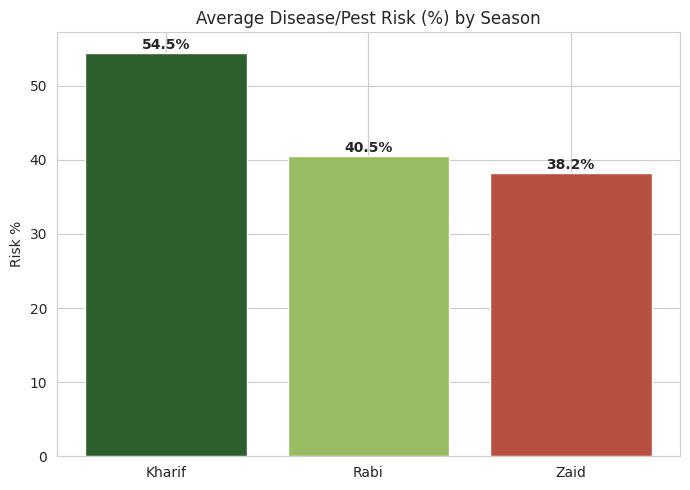

In [21]:
disease_by_season = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(season_order)

plt.figure(figsize=(7,5))
plt.bar(disease_by_season.index, disease_by_season.values, color=colors)
plt.title('Average Disease/Pest Risk (%) by Season')
plt.ylabel('Risk %')
for i, v in enumerate(disease_by_season.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_disease_risk.png', dpi=150)
plt.show()

Kharif has noticeably higher pest/disease risk than Rabi and Zaid, most likely because the humid, rainy monsoon conditions are more favourable for pests and fungal diseases.

## 12. Are the Seasonal Patterns Consistent Across States?

Checking whether the Kharif > Rabi > Zaid profit pattern holds regardless of region, or if it's only true for specific states.

In [22]:
top_states = df['State'].value_counts().head(6).index
state_season_profit = df[df['State'].isin(top_states)].pivot_table(
    values='Profit_INR', index='State', columns='Season', aggfunc='mean').round(0)
state_season_profit = state_season_profit[season_order]
state_season_profit

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Telangana,199668.0,62825.0,-34621.0


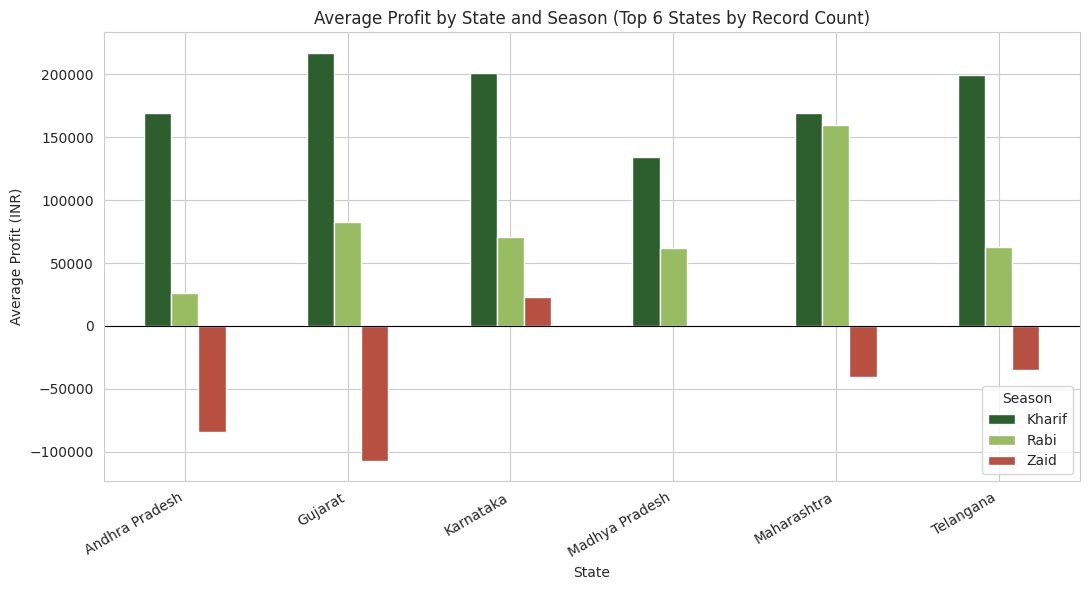

In [23]:
state_season_profit.plot(kind='bar', figsize=(11,6), color=colors)
plt.title('Average Profit by State and Season (Top 6 States by Record Count)')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.savefig('chart_state_season_profit.png', dpi=150)
plt.show()

The general pattern (Kharif best, Zaid worst) holds across most states, which means this is a genuine seasonal effect and not just a one-region issue.

## 13. Key Insights

1. **Kharif** is the strongest season overall - highest average yield (~5.6 t/ha) and highest average profit (~₹1.79 lakh/farm), largely supported by monsoon rainfall.
2. **Zaid** is the weakest season - it runs at an average **loss** (~-₹24,805/farm), driven by higher average temperature and lower rainfall, pushing up irrigation dependence and cost.
3. **Rabi** sits in between, with moderate yield and a solid positive average profit.
4. **Profit differs very significantly across seasons** (ANOVA), and once crop type is held constant, **yield differences across seasons are significant too** - the seasonal effect is real, it's just masked in the raw pooled-yield numbers by how much yield scale varies from crop to crop (e.g. Sugarcane vs Pulses).
5. **Drip irrigation gives the best profit in Kharif and Rabi**, but in Zaid, **Sprinkler irrigation performs slightly better than Drip** - both stay profitable in Zaid while Flood and Rainfed run losses in every season they're compared in Zaid.
6. **Disease/pest risk is highest in Kharif** due to humid monsoon conditions, and lowest in Zaid - matching the strong correlation between rainfall/humidity and disease risk.
7. The Kharif > Rabi > Zaid pattern holds for almost every crop and across most states, so it's a genuine seasonal effect rather than a one-crop or one-region issue.

## 14. Recommendations

- Farmers growing in the **Zaid** season and currently using **Flood or Rainfed irrigation** should be supported to shift to **Drip or Sprinkler**, since those are the only two methods that stay profitable in that season.
- Extra pest-management support (subsidised pesticide, advisory alerts) should be prioritised during **Kharif**, when disease/pest risk is at its peak.
- Crop insurance and financial planning tools should account for the **higher variability in Zaid**, where outcomes range from reasonable profit to heavy loss.
- Given the strong seasonal effect, agricultural extension programs should give **season-specific advisory** (irrigation, fertilizer, sowing time) rather than one generic recommendation for the whole year.
